**Let's talk about the Dataset first!**



https://www.kaggle.com/competitions/titanic

# Exploratory Data Analysis

In [121]:
# loading the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import *

In [122]:
# loading the dataset
df = pd.read_csv("/content/titanic_train.csv")

In [123]:
# basic exploration

In [124]:
df.shape

(891, 12)

In [125]:
# viewing the first and last 5 elements

In [126]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [127]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [129]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Data Cleaning
1. Handling Missing values
2. Outlier Handling

In [130]:
# looking for missing values in features

In [131]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Note: In the Cabin column we have 687 missing values, which makes up 77% of the column, the general rule of thumb is if we have more than 25% missing values in a column then we drop it**

Filling the missing data

In [132]:
# filling Embarked column

In [133]:
df["Embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

/tmp/ipykernel_1005/1084143471.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df["Embarked"], palette = "pastel")


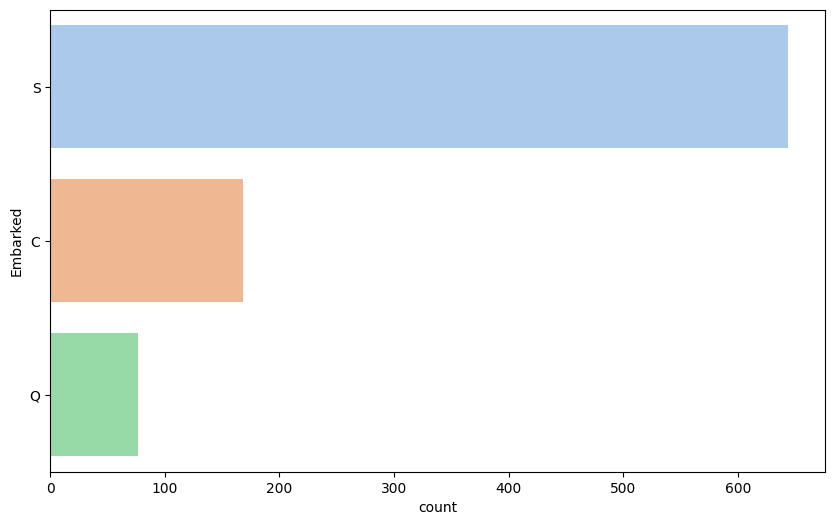

In [134]:
plt.figure(figsize = (10,6))

sns.countplot(df["Embarked"], palette = "pastel")
plt.show()

In [135]:
emb_i = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(emb_i)

In [136]:
df["Embarked"].isna().sum()

np.int64(0)

In [137]:
# filling Age column

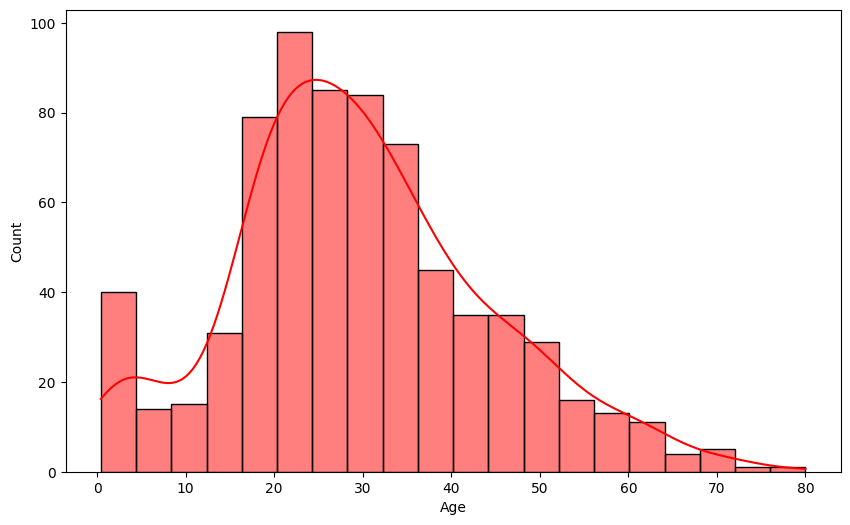

In [138]:
plt.figure(figsize = (10,6))

sns.histplot(data = df, x = "Age", color = "red", kde = True)
plt.show()

In [139]:
df[df['Age'].isna()][['Sex', 'Parch', 'SibSp', 'Age']]

,Sex,Parch,SibSp,Age
5,male,0,0,NaN
17,male,0,0,NaN
19,female,0,0,NaN
26,male,0,0,NaN
28,female,0,0,NaN
...,...,...,...,...
859,male,0,0,NaN
863,female,2,8,NaN
868,male,0,0,NaN
878,male,0,0,NaN


In [140]:
df.groupby(["Pclass"])["Age"].mean()

,Age
Pclass,
1,38.233441
2,29.877630
3,25.140620


In [141]:
# checking what impacts Age

In [142]:
df[["Pclass",	"Age",	"SibSp",	"Parch","Fare"]].corr()["Age"]

,Age
Pclass,-0.369226
Age,1.000000
SibSp,-0.308247
Parch,-0.189119
Fare,0.096067


In [143]:
df["Age"] = df.groupby(["Sex", "Parch", "SibSp"])["Age"].transform(lambda x: x.fillna(x.median()))

In [144]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,7
SibSp,0
Parch,0
Ticket,0
Fare,0


In [145]:
#why are there still 7 missing values in Age thus we shall impute them with global median

In [146]:
age_i = df["Age"].median()
df["Age"] = df["Age"].fillna(age_i)

In [147]:
df["Age"].isna().sum()

np.int64(0)

In [148]:
# handling outliers (Optional for this dataset)


**Note: Outliers are data points that stands apart from the rest of the group. Because these points deviate extremely,
they are often treated as exceptions and need to removed**

In [149]:
# outliers in Fare columnn

<Axes: ylabel='Fare'>

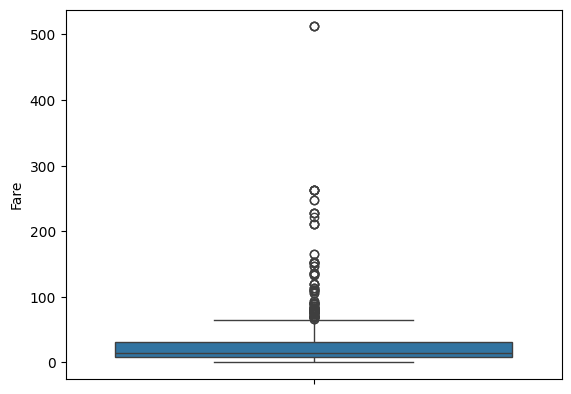

In [150]:
sns.boxplot(df["Fare"])

In [151]:
#there are a lot of high outliers in Fare
Q1 = df["Fare"].quantile(0.25) #industry prefers 0.05
Q3 = df["Fare"].quantile(0.75) #industry prefers 0.95
IQR = Q3 - Q1


In [152]:
# min and max outliers
Minimum = max(Q1 - (1.5 * IQR),0)
Maximum = Q3 + (1.5 * IQR)

In [153]:
print(Minimum, Maximum)

0 65.6344


In [154]:
# df = df[df["Fare"] <= Maximum]

**Note: We will not be filtering the outliers as it is leading to less accuracy**

# Feature Engineering


**Handling Numeric Columns**

In [155]:
# creating bins

In [156]:
age_bins = [0, 12, 19, 30, 65, 120]
age_labels = ["Child", "Teenager", "Young Adult", "Adult", "Senior"]

In [157]:
df["Age_bin"] = pd.cut(df["Age"], bins = age_bins, labels = age_labels)

In [158]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_bin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult


In [159]:
df["Fare_bin"] = pd.qcut(df["Fare"], q=4, labels = ['Low','Medium','High','Premium'])

In [160]:
print("Binned Features Preview:")
df[['Age', 'Age_bin', 'Fare', 'Fare_bin']].head()

Binned Features Preview:


,Age,Age_bin,Fare,Fare_bin
0,22.0,Young Adult,7.2500,Low
1,38.0,Adult,71.2833,Premium
2,26.0,Young Adult,7.9250,Medium
3,35.0,Adult,53.1000,Premium
4,35.0,Adult,8.0500,Medium


**Manual Feature Engineering**

In [161]:
# A. FamilySize: Combining SibSp (Siblings/Spouses) and Parch (Parents/Children)
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

# B. IsAlone: Binary indicator if the passenger travelled solo
df['Is_Alone'] = np.where(df['Family_Size'] == 1, 1, 0)

In [162]:
# Extract the first letter of the Cabin string; fill missing ones with 'Unknown'
df["Deck"] = df["Cabin"].str[0].fillna("U")
# Group rare or problematic decks (like 'T' or 'G') into adjacent classes
df['Deck'] = df['Deck'].replace(['T', 'G'], 'Rare_Deck')

# df = pd.get_dummies(df, columns=['Deck'], drop_first=True)

In [163]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_bin,Fare_bin,Family_Size,Is_Alone,Deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Young Adult,Low,2,0,U
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult,Premium,2,0,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Young Adult,Medium,1,1,U
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult,Premium,2,0,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult,Medium,1,1,U


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     891 non-null    object  
 12  Age_bin      891 non-null    category
 13  Fare_bin     891 non-null    category
 14  Family_Size  891 non-null    int64   
 15  Is_Alone     891 non-null    int64   
 16  Deck         891 non-null    object  
dtypes: category(2), float64(2), int64(7), object(6)
memory usage: 106.7+ KB


In [165]:
# Drop raw unencoded text/ID columns to finalize the feature space matrix

In [166]:
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Age', 'Fare']
df = df.drop(columns = columns_to_drop, errors='ignore')

In [167]:
# Encoding

In [168]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, KBinsDiscretizer
from sklearn.pipeline import Pipeline

In [169]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify numerical and categorical features from the current X
# Based on df.info() after dropping columns:
# X contains: Pclass, Sex, SibSp, Parch, Embarked, Age_bin, Family_Size, Is_Alone, Deck, Fare_bin

numerical_features = ['Pclass', 'SibSp', 'Parch', 'Family_Size', 'Is_Alone']
categorical_features = ['Sex', 'Embarked', 'Age_bin', 'Deck', 'Fare_bin']

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='passthrough' # Keep any other columns not specified
)

# Train Test Splitting

In [170]:
from sklearn.model_selection import train_test_split
# Ensure pandas is imported for DataFrame creation
import pandas as pd

# Defining Features X and y
X = df.drop(columns = "Survived", axis = 1)
y = df["Survived"]

# Split the data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)



In [171]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# assembling the pipeline

In [172]:
model_pipeline = Pipeline(
    steps = [
        ("Preprocess",preprocessor),
        ("Model",RandomForestClassifier())
    ]
)

In [173]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Pclass', 'SibSp', 'Parch',
                                                   'Family_Size', 'Is_Alone']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Sex', 'Embarked', 'Age_bin',
                                                   'Deck', 'Fare_bin'])])),
                ('Model', RandomForestClassifier())])

In [174]:
y_train_mean = y_train.mean()


In [175]:
y_pred = model_pipeline.predict(X_test)

In [176]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy}")

Accuracy Score: 0.8100558659217877


# Test Data

In [177]:
test_df = pd.read_csv("/content/titanic_test.csv")

In [178]:
passenger_ids = test_df['PassengerId']

In [179]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [180]:
test_df.isna().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [181]:
# filling the fare column
test_df["Fare"] = test_df["Fare"].fillna(test_df["Fare"].median())

In [182]:
# filling the age column
test_df["Age"] = test_df.groupby(["Sex", "Parch", "SibSp"])["Age"].transform(lambda x: x.fillna(x.median()))
test_df["Age"] = test_df["Age"].fillna(test_df["Age"].median())

In [183]:
# Replicating the Feature Engineering
age_bins = [0, 12, 19, 30, 65, 120]
age_labels = ["Child", "Teenager", "Young Adult", "Adult", "Senior"]
test_df["Age_bin"] = pd.cut(test_df["Age"], bins=age_bins, labels=age_labels)

In [184]:
test_df["Fare_bin"] = pd.qcut(test_df["Fare"], q=4, labels=['Low','Medium','High','Premium'], duplicates='drop')

test_df['Family_Size'] = test_df['SibSp'] + test_df['Parch'] + 1
test_df['Is_Alone'] = np.where(test_df['Family_Size'] == 1, 1, 0)

In [185]:
test_df["Deck"] = test_df["Cabin"].str[0].fillna("U")
test_df['Deck'] = test_df['Deck'].replace(['T', 'G'], 'Rare_Deck')

In [186]:
# Drop the raw columns
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Age', 'Fare']
X_test_kaggle = test_df.drop(columns=columns_to_drop, errors='ignore')

**Generating Predictions**

In [187]:
kaggle_predictions = model_pipeline.predict(X_test_kaggle)

In [188]:
submission_df = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": kaggle_predictions
})

In [189]:
submission_df.to_csv("my_titanic_submission.csv", index=False)

In [190]:
submission_df.shape

(418, 2)

In [ ]:
# downloading .pkl file and cleaned dataset

In [191]:
# import joblib

# joblib.dump(model_pipeline, 'Titanic_Survival_Predictor.pkl')

# # Trigger the download to your local machine
# from google.colab import files
# files.download('Titanic_Survival_Predictor.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [192]:
# from google.colab import files

# # 1. Save your DataFrame to a CSV file
# # Note: index=False prevents Pandas from adding a column of row numbers!
# df.to_csv('titanic_train_clean_dataset.csv', index=False)

# # 2. Trigger the browser download
# files.download('titanic_train_clean_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>